# TrustLens — Dataset Research & Exploration

## Phase 3: Dataset Exploration, Feature Engineering and Selection

**Project:** TrustLens — AI-Based Website Trust & Phishing Risk Analyzer

This notebook documents the dataset exploration and preprocessing stage of TrustLens.

The objectives of this notebook are to:

- Understand the structure of the phishing URL dataset.
- Examine data quality and class distribution.
- Perform Exploratory Data Analysis (EDA).
- Analyze relationships between URL features and the target label.
- Engineer additional URL-based lexical features.
- Identify dataset limitations and possible biases.
- Select a reproducible URL-based feature set for machine learning.
- Prepare and save the cleaned dataset for model development.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, URL parsing, and basic file operations.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import urlparse

## 2. Load the Dataset

The PhiUSIIL Phishing URL Dataset is used for this project.

The dataset contains legitimate and phishing URLs along with multiple lexical, domain-based, and webpage-related features.

In [2]:
DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


## 3. Dataset Overview

Before performing preprocessing or machine learning, the dataset structure is inspected to understand:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Statistical characteristics

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 235795
Number of columns: 55

Column names:
['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  str    
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  str    
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  str    
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscatedChar       

### Initial Observation

The dataset contains **235,795 records and 55 columns**.

It includes:

- Raw textual information such as URL, domain, TLD, and title
- Numerical URL and domain characteristics
- Webpage-based attributes
- A binary target column named `label`

The target encoding used in the dataset is:

- **0 → Phishing**
- **1 → Legitimate**

## 4. Data Quality Assessment

Before performing EDA, the dataset is checked for:

- Missing values
- Duplicate URLs
- Conflicting target labels

In [5]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [6]:
duplicate_urls = df["URL"].duplicated().sum()

conflicting_labels = (
    df.groupby("URL")["label"]
      .nunique()
)

conflicting_urls = conflicting_labels[conflicting_labels > 1]

print("Duplicate URLs:", duplicate_urls)
print("URLs with conflicting labels:", len(conflicting_urls))

Duplicate URLs: 425
URLs with conflicting labels: 0


### Data Quality Findings

- No missing values were found in the dataset.
- 425 duplicate URLs were identified.
- No URL appeared with conflicting phishing and legitimate labels.

Duplicate URLs will be removed before preparing the final machine-learning dataset to reduce the possibility of repeated samples influencing model evaluation.

## 5. Target Class Distribution

The distribution of phishing and legitimate URLs is examined to determine whether the dataset contains a major class imbalance.

The target labels are:

- **0 → Phishing**
- **1 → Legitimate**

In [7]:
class_counts = df["label"].value_counts().sort_index()
class_proportions = df["label"].value_counts(normalize=True).sort_index()

print("Class Counts:")
print(class_counts)

print("\nClass Proportions:")
print(class_proportions)

Class Counts:
label
0    100945
1    134850
Name: count, dtype: int64

Class Proportions:
label
0    0.428105
1    0.571895
Name: proportion, dtype: float64


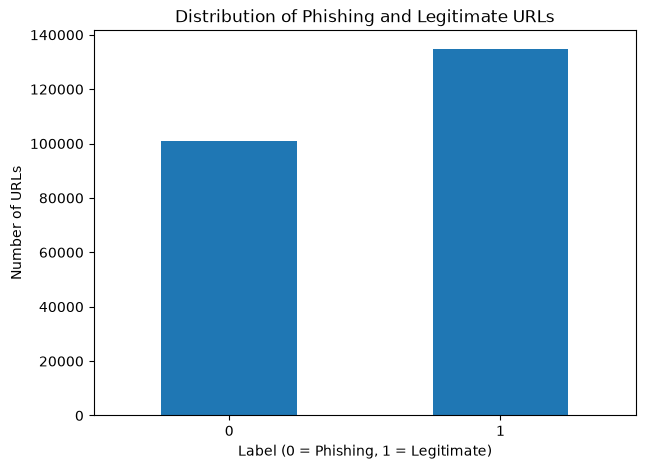

In [8]:
class_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Phishing and Legitimate URLs")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of URLs")
plt.xticks(rotation=0)
plt.show()

### Class Distribution Observation

The dataset contains approximately:

- **43% phishing URLs**
- **57% legitimate URLs**

Although legitimate URLs are slightly more common, the difference is not severe enough to indicate a major class imbalance. Therefore, no resampling technique is applied at this stage.

## 6. Exploratory Data Analysis

### 6.1 URL Length

URL length is a lexical characteristic that may provide useful information for phishing detection.

Attackers may sometimes use long or complex URLs to hide suspicious domains or include misleading parameters. However, URL length alone cannot determine whether a website is phishing.

In [9]:
df["URLLength"].describe()

count    235795.000000
mean         34.573095
std          41.314153
min          13.000000
25%          23.000000
50%          27.000000
75%          34.000000
max        6097.000000
Name: URLLength, dtype: float64

In [10]:
url_length_by_label = df.groupby("label")["URLLength"].mean()

print(url_length_by_label)

label
0    45.720293
1    26.228610
Name: URLLength, dtype: float64


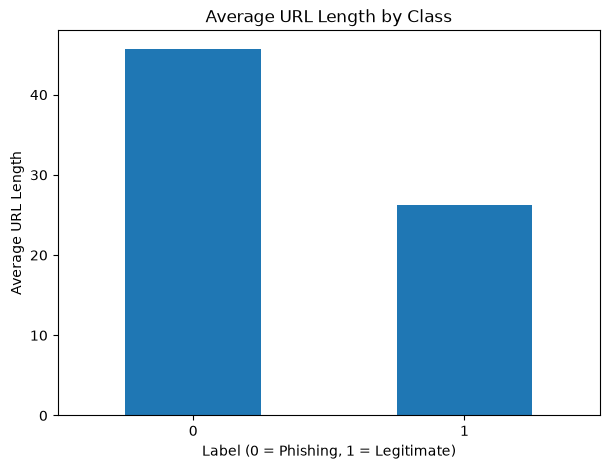

In [11]:
url_length_by_label.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average URL Length by Class")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Average URL Length")
plt.xticks(rotation=0)
plt.show()

### URL Length Observation

Phishing URLs in the dataset are longer on average than legitimate URLs.

This suggests that URL length may provide useful information to the machine-learning model. However, long URLs are not inherently malicious, so this feature should be interpreted together with other URL characteristics.

### 6.2 HTTPS Usage

HTTPS encrypts communication between a user's browser and a website.

Although HTTPS is an important security mechanism, its presence does not guarantee that a website is legitimate because phishing websites can also obtain SSL/TLS certificates.

In [12]:
https_by_label = df.groupby("label")["IsHTTPS"].mean()

print(https_by_label)

label
0    0.492238
1    1.000000
Name: IsHTTPS, dtype: float64


### HTTPS Observation

HTTPS usage is considerably more common among legitimate URLs in this dataset.

However, all legitimate samples having HTTPS indicates a possible dataset-specific pattern. Therefore, HTTPS should be treated as one signal among many rather than proof that a website is safe.

### 6.3 Selected Feature Comparison

Several existing dataset features are compared between phishing and legitimate URLs to understand how their average values differ between the two classes.

### Selected Feature Findings

The exploratory comparison reveals several notable patterns:

- Phishing URLs tend to be longer than legitimate URLs.
- HTTPS is more common among legitimate samples, although HTTPS alone does not guarantee trustworthiness.
- Features such as 'HasSocialNet' and 'HasCopyrightInfo' show large differences between the two classes.
- 'URLSimilarityIndex' shows an unusually strong separation between phishing and legitimate samples.
- Some highly predictive features depend on webpage content or dataset-specific calculations and may not be reproducible from a newly submitted URL.

Therefore, high statistical association alone is not sufficient for selecting features for TrustLens.

## 7. Correlation Analysis

Correlation analysis is used to examine the relationship between numerical features and the target label.

Since the target is encoded as:

- **0 → Phishing**
- **1 → Legitimate**

a positive correlation indicates that higher feature values are associated with legitimate URLs, while a negative correlation indicates association with phishing URLs.

The magnitude of the correlation indicates the strength of the relationship.

### Absolute Correlation

For feature ranking, absolute correlation is also considered.

This allows both strong positive and strong negative relationships to be identified. For example, a correlation of `-0.70` represents a stronger relationship than a correlation of `+0.20`, even though its numerical value is smaller.

In [13]:
numeric_df = df.select_dtypes(include=["number"])

correlation_with_label = (
    numeric_df.corr()["label"]
    .drop("label")
    .sort_values(ascending=False)
)

correlation_with_label

URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
Robots                        0.392620
NoOfJS                        0.373500
Pay                           0.359747
NoOfSelfRef                   0.316211
NoOfImage                     0.274658
LineOfCode                    0.272257
NoOfExternalRef               0.258627
NoOfiFrame                    0.225822
Bank                          0.188959
HasExternalFormSubmit         0.167574
HasPasswordField              0.138183
NoOfEmptyRef             

In [14]:
top_correlations = (
    correlation_with_label
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

top_features = top_correlations.index

top_original_correlations = correlation_with_label[top_features]

top_original_correlations

URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
Name: label, dtype: float64

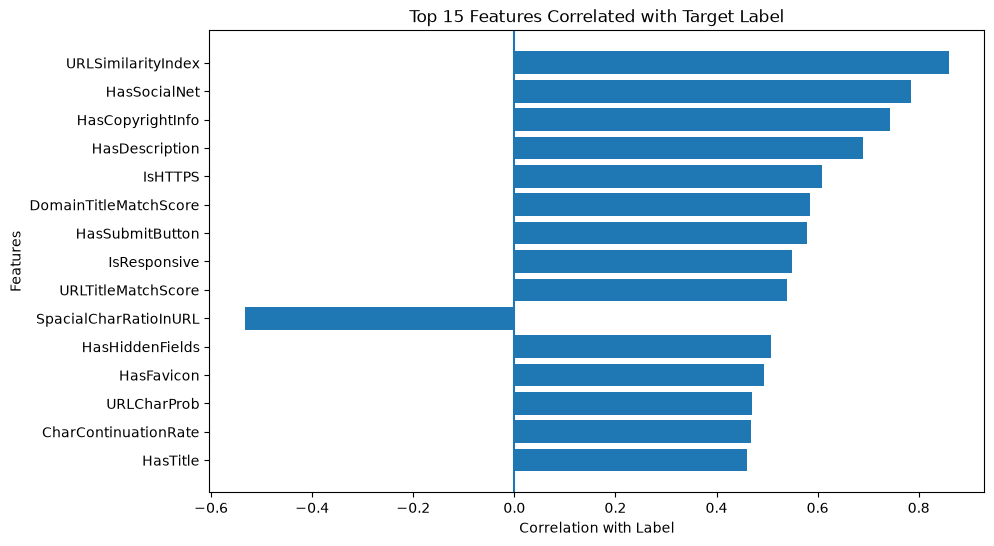

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_original_correlations.index,
    top_original_correlations.values
)

plt.title("Top 15 Features Correlated with Target Label")
plt.xlabel("Correlation with Label")
plt.ylabel("Features")

plt.axvline(x=0)
plt.gca().invert_yaxis()

plt.show()

### Correlation Findings

Several features show strong relationships with the target label, including:

- `URLSimilarityIndex`
- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `IsHTTPS`
- `DomainTitleMatchScore`

However, correlation does not imply that a feature should automatically be used by the final model.

Some highly correlated features require webpage content, while others may depend on dataset-specific calculations that cannot be reliably reproduced when a user submits a new URL.

For this reason, feature selection for TrustLens considers both predictive information and deployment feasibility.

## 8. Feature Feasibility for TrustLens

The PhiUSIIL dataset contains both URL-derived and webpage-derived features.

For TrustLens V1, the machine-learning model is designed primarily around features that can be reproducibly extracted from a URL submitted by the user.

Examples of URL-derived information include:

- URL length
- Domain length
- HTTPS usage
- Number of subdomains
- Digit and character ratios
- Special-character counts
- Domain IP usage

Other features require downloading and analyzing webpage content, such as:

- Social-network links
- Copyright information
- Page description
- Submit buttons
- Hidden fields
- Images, CSS, and JavaScript counts

These webpage-derived features may still be useful for rule-based analysis or future versions of TrustLens, but they are not automatically included in the V1 lexical machine-learning model.

### Feature Selection Principle

A feature is considered suitable for the V1 machine-learning model when it satisfies the following principles:

1. It provides potentially useful information for phishing detection.
2. It can be consistently calculated for new user-submitted URLs.
3. Its definition can be implemented and explained clearly.
4. It does not rely heavily on an obvious dataset-specific artifact.
5. It does not introduce unnecessary redundancy with another feature.

Therefore, the strongest correlation with the target is not the only criterion used for feature selection.

## 9. Feature Engineering

In addition to the existing dataset attributes, several lexical features are engineered directly from the raw URL.

The engineered features are:

- `NoOfDots` — number of dots in the URL
- `NoOfSlashes` — number of slash characters in the URL
- `SuspiciousKeywordCount` — number of selected phishing-related terms present in the URL
- `HasHyphenInDomain` — whether the hostname contains a hyphen
- `PathDepth` — number of non-empty path segments

These features are investigated as candidate signals rather than assumed to indicate phishing by themselves.

In [16]:
SUSPICIOUS_KEYWORDS = [
    "login",
    "verify",
    "secure",
    "account",
    "update",
    "signin",
    "banking",
    "confirm",
    "password"
]


def count_suspicious_keywords(url):
    url = url.lower()

    return sum(
        keyword in url
        for keyword in SUSPICIOUS_KEYWORDS
    )


def has_hyphen_in_domain(url):
    hostname = urlparse(url).hostname

    if hostname is None:
        return 0

    return int("-" in hostname)


def calculate_path_depth(url):
    path = urlparse(url).path
    parts = [part for part in path.split("/") if part]

    return len(parts)

In [17]:
df["NoOfDots"] = df["URL"].str.count(r"\.")
df["NoOfSlashes"] = df["URL"].str.count("/")

df["SuspiciousKeywordCount"] = df["URL"].apply(
    count_suspicious_keywords
)

df["HasHyphenInDomain"] = df["URL"].apply(
    has_hyphen_in_domain
)

df["PathDepth"] = df["URL"].apply(
    calculate_path_depth
)

engineered_features = [
    "NoOfDots",
    "NoOfSlashes",
    "SuspiciousKeywordCount",
    "HasHyphenInDomain",
    "PathDepth"
]

df[engineered_features].head()

,NoOfDots,NoOfSlashes,SuspiciousKeywordCount,HasHyphenInDomain,PathDepth
0,2,2,0,0,0
1,2,2,0,1,0
2,3,2,0,0,0
3,2,2,0,0,0
4,2,2,0,0,0


In [18]:
engineered_feature_comparison = (
    df.groupby("label")[engineered_features]
      .mean()
      .T
)

engineered_feature_comparison.columns = [
    "Phishing (0)",
    "Legitimate (1)"
]

engineered_feature_comparison

,Phishing (0),Legitimate (1)
NoOfDots,2.384695,2.161661
NoOfSlashes,3.019208,2.000000
SuspiciousKeywordCount,0.076715,0.000882
HasHyphenInDomain,0.312011,0.074631
PathDepth,0.588548,0.000000


### Engineered Feature Findings

The engineered features reveal several patterns:

- Phishing URLs contain slightly more dots on average.
- Phishing URLs contain more slash characters on average.
- Suspicious keywords occur more frequently in phishing URLs.
- Hyphens in the hostname are considerably more common among phishing URLs.
- Phishing URLs have greater path depth on average.

However, `NoOfSlashes` and `PathDepth` reveal an important dataset-specific pattern: legitimate URLs in this dataset have no path depth and approximately only the protocol slashes.

Real legitimate websites can contain complex paths. Therefore, these features are treated cautiously and are not automatically selected for the final model.

This demonstrates the importance of identifying dataset artifacts rather than relying only on apparently strong predictive patterns.

## 10. Candidate Feature Selection

A candidate feature set is created using reproducible URL-derived attributes from the original dataset together with the newly engineered lexical features.

These features will be evaluated for missing values, variation, redundancy, reproducibility, and possible dataset-specific bias before defining the final machine-learning feature set.

In [19]:
original_url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

candidate_features = original_url_features + engineered_features

X_candidate = df[candidate_features]
y = df["label"]

print("Candidate feature count:", len(candidate_features))
print("X shape:", X_candidate.shape)
print("y shape:", y.shape)

Candidate feature count: 23
X shape: (235795, 23)
y shape: (235795,)


## 11. Candidate Feature Quality Checks

Before final feature selection, the candidate features are checked for:

- Missing values
- Constant or low-variation features
- Highly correlated features

In [20]:
print(
    "Total missing values:",
    X_candidate.isnull().sum().sum()
)

print(
    "\nUnique values per feature:"
)

X_candidate.nunique().sort_values()

Total missing values: 0

Unique values per feature:


IsDomainIP                      2
HasObfuscation                  2
HasHyphenInDomain               2
IsHTTPS                         2
NoOfQMarkInURL                  5
SuspiciousKeywordCount          5
NoOfSubDomain                  10
TLDLength                      12
NoOfObfuscatedChar             20
NoOfEqualsInURL                25
PathDepth                      26
NoOfDots                       27
NoOfSlashes                    29
NoOfAmpersandInURL             31
NoOfOtherSpecialCharsInURL     74
DomainLength                  101
ObfuscationRatio              146
NoOfDegitsInURL               182
SpacialCharRatioInURL         240
NoOfLettersInURL              421
URLLength                     482
DegitRatioInURL               575
LetterRatioInURL              709
dtype: int64

### 11.1 Binary Feature Distribution

Binary features are examined to identify attributes where one value occurs extremely rarely.

Rare features are not automatically removed because an uncommon characteristic may still provide useful cybersecurity information.

In [21]:
binary_features = [
    "IsDomainIP",
    "HasObfuscation",
    "HasHyphenInDomain",
    "IsHTTPS"
]

for feature in binary_features:
    print(f"\n{feature}")
    print(df[feature].value_counts(normalize=True))


IsDomainIP
IsDomainIP
0    0.997294
1    0.002706
Name: proportion, dtype: float64

HasObfuscation
HasObfuscation
0    0.997943
1    0.002057
Name: proportion, dtype: float64

HasHyphenInDomain
HasHyphenInDomain
0    0.823745
1    0.176255
Name: proportion, dtype: float64

IsHTTPS
IsHTTPS
1    0.782625
0    0.217375
Name: proportion, dtype: float64


### Binary Feature Observation

`IsDomainIP` and `HasObfuscation` are near-constant features because positive values occur in a very small proportion of the dataset.

However, rarity alone is not sufficient reason for removal. For example, direct IP-address usage may be uncommon but can still provide meaningful information during phishing analysis.

`HasObfuscation` and its related attributes require additional caution because the exact dataset-specific calculation must be reproducible for new URLs.

## 12. Feature Redundancy Analysis

Highly correlated input features may represent overlapping information.

An absolute correlation threshold of **0.85** is used as a screening criterion to identify feature pairs that deserve further investigation. This threshold is used for analysis rather than automatic feature removal.

In [22]:
correlation_matrix = X_candidate.corr().abs()

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > 0.85:
            high_correlation_pairs.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i, j]
                )
            )

high_correlation_pairs

[('NoOfLettersInURL', 'URLLength', np.float64(0.9560469859044239)),
 ('PathDepth', 'NoOfSlashes', np.float64(0.8865946379450328))]

### Redundancy Findings

Two strongly correlated feature pairs were identified:

1. `URLLength` and `NoOfLettersInURL`
2. `NoOfSlashes` and `PathDepth`

`URLLength` is preferred over `NoOfLettersInURL` because it is simpler, directly reproducible, and already captures much of the same information.

`NoOfSlashes` and `PathDepth` are both related to URL path structure. In addition to their redundancy, both exhibit a strong dataset-specific pattern among legitimate samples. They are therefore excluded from the provisional V1 feature set.

## 13. Duplicate Removal

Duplicate URLs are removed before model development.

Keeping repeated URLs could allow identical samples to appear in both training and testing data after a random split, potentially producing an overly optimistic evaluation.

No conflicting labels were found among duplicate URLs.

In [23]:
rows_before = len(df)

df = (
    df.drop_duplicates(subset="URL")
      .reset_index(drop=True)
)

rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Remaining duplicate URLs:", df["URL"].duplicated().sum())

Rows before: 235795
Rows after: 235370
Rows removed: 425
Remaining duplicate URLs: 0


## 14. Final Selected Feature Set

Based on exploratory analysis, reproducibility, redundancy, and identified dataset limitations, a provisional set of 17 URL-derived features is selected for model development.

The following candidate features are excluded:

- `NoOfLettersInURL` — highly redundant with `URLLength`
- `HasObfuscation`, `NoOfObfuscatedChar`, `ObfuscationRatio` — exact extraction methodology requires further verification
- `NoOfSlashes`, `PathDepth` — strong dataset-specific path pattern and redundancy

These exclusions do not imply that the features are universally useless. They are excluded from the current TrustLens V1 model to maintain a reproducible and defensible feature pipeline.

In [24]:
selected_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "NoOfDots",
    "SuspiciousKeywordCount",
    "HasHyphenInDomain"
]

X_selected = df[selected_features]
y = df["label"]

print("Selected feature count:", len(selected_features))
print("X shape:", X_selected.shape)
print("y shape:", y.shape)

Selected feature count: 17
X shape: (235370, 17)
y shape: (235370,)


In [25]:
print(
    "Missing values:",
    X_selected.isnull().sum().sum()
)

print(
    "Duplicate URLs:",
    df["URL"].duplicated().sum()
)

print("\nFinal class distribution:")
print(y.value_counts())

print("\nFinal class proportions:")
print(y.value_counts(normalize=True))

Missing values: 0
Duplicate URLs: 0

Final class distribution:
label
1    134850
0    100520
Name: count, dtype: int64

Final class proportions:
label
1    0.572928
0    0.427072
Name: proportion, dtype: float64


## 15. Save the Processed Dataset

After duplicate removal and feature engineering, the processed master dataset is saved for use in the machine-learning development phase.

The complete processed dataset is preserved rather than saving only the 17 selected features. This retains the raw URL, target label, engineered features, and other dataset attributes for future analysis and experimentation.

In [26]:
OUTPUT_PATH = "../data/processed/PhiUSIIL_clean.csv"

df.to_csv(OUTPUT_PATH, index=False)

print("Processed dataset saved successfully.")
print("Saved to:", OUTPUT_PATH)
print("Final dataset shape:", df.shape)

Processed dataset saved successfully.
Saved to: ../data/processed/PhiUSIIL_clean.csv
Final dataset shape: (235370, 60)


In [27]:
processed_df = pd.read_csv(OUTPUT_PATH)

print("Saved file exists:", os.path.exists(OUTPUT_PATH))
print("Loaded shape:", processed_df.shape)
print("Duplicate URLs:", processed_df["URL"].duplicated().sum())
print("Missing values:", processed_df[selected_features].isnull().sum().sum())

Saved file exists: True
Loaded shape: (235370, 60)
Duplicate URLs: 0
Missing values: 0


## 17. Phase 3 Summary

Dataset research, exploratory data analysis, feature engineering, and feature selection for TrustLens have been completed.

### Final Dataset

- Original samples: **235,795**
- Duplicate URLs removed: **425**
- Final samples: **235,370**
- Missing values in selected features: **0**
- Final class distribution:
  - Legitimate: approximately **57.3%**
  - Phishing: approximately **42.7%**

### Feature Engineering

Five additional lexical features were investigated:

- `NoOfDots`
- `NoOfSlashes`
- `SuspiciousKeywordCount`
- `HasHyphenInDomain`
- `PathDepth`

### Feature Selection

A provisional set of **17 reproducible URL-derived features** was selected for machine-learning development.

Feature selection was based not only on correlation with the target, but also on:

- Reproducibility for new URLs
- Cybersecurity relevance
- Feature redundancy
- Dataset-specific artifacts
- Deployment feasibility

### Important Dataset Observations

EDA revealed several unusually strong patterns, including HTTPS usage and URL path characteristics among legitimate samples. These patterns will be treated cautiously during model evaluation because high predictive performance may partly reflect characteristics of the dataset rather than general phishing behaviour.

The next phase will train and compare machine-learning models using the selected feature set and evaluate their ability to generalize to unseen URLs.